# SIMULATION OF SINUSOID GAUSSIAN-MODULATED ELECTROMAGNETIC WAVE IN TWO DIFFERENT MEDIUMS USING FDTD WITH ABSORBING BOUNDARY CONDITION


## Finite-Difference Time-Domain (FDTD)

Dalam metode FDTD, medan listrik dan medan magnet diperbarui secara bergantian di grid diskret berdasarkan pendekatan beda hingga terhadap turunan ruang dan waktu. Berikut adalah bentuk umum dari persamaan FDTD yang digunakan untuk memodelkan penyebaran gelombang elektromagnetik dalam ruang dua dimensi (2D) dengan komponen medan $E_z$, $H_x$, dan $H_y$:

### **1. Persamaan Pembaruan Medan Magnet**

Komponen medan magnet diperbarui terlebih dahulu pada setiap langkah waktu setengah ($n+\frac{1}{2}$) menggunakan perbedaan medan listrik pada grid spasial:

* **Pembaruan $H_x$:**

$$
H_x^{n+\frac{1}{2}}(i,j) = H_x^{n-\frac{1}{2}}(i,j) - \frac{\Delta t}{\mu \Delta y} \left[ E_z^n(i,j+1) - E_z^n(i,j) \right]
$$

* **Pembaruan $H_y$:**

$$
H_y^{n+\frac{1}{2}}(i,j) = H_y^{n-\frac{1}{2}}(i,j) + \frac{\Delta t}{\mu \Delta x} \left[ E_z^n(i+1,j) - E_z^n(i,j) \right]
$$

Kedua persamaan ini merepresentasikan interaksi antara perubahan medan listrik dengan medan magnet di grid tetangga pada arah $x$ dan $y$.

---

### **2. Persamaan Pembaruan Medan Listrik**

Setelah medan magnet diperbarui, medan listrik $E_z$ diperbarui menggunakan hasil perhitungan curl medan magnet pada langkah waktu penuh ($n+1$):

$$
E_z^{n+1}(i,j) = E_z^{n}(i,j) + \frac{\Delta t}{\varepsilon(i,j)} \left\{ \frac{H_y^{n+\frac{1}{2}}(i,j) - H_y^{n+\frac{1}{2}}(i-1,j)}{\Delta x} - \frac{H_x^{n+\frac{1}{2}}(i,j) - H_x^{n+\frac{1}{2}}(i,j-1)}{\Delta y} \right\}
$$

Persamaan ini menunjukkan bahwa perubahan medan listrik di titik grid tertentu dipengaruhi oleh perbedaan spasial medan magnet di sekitarnya.

---

### **3. Syarat Stabilitas (Kondisi Courant)**

Agar simulasi FDTD stabil dan tidak divergen, interval waktu diskret $\Delta t$ harus memenuhi kondisi Courant:

$$
\Delta t \leq \frac{1}{c \sqrt{\left(\frac{1}{\Delta x^2} + \frac{1}{\Delta y^2}\right)}}
$$

Kondisi ini memastikan bahwa gelombang elektromagnetik tidak melangkah lebih jauh dari satu grid spasial dalam satu langkah waktu.





<>:155: SyntaxWarning: invalid escape sequence '\I'
<>:155: SyntaxWarning: invalid escape sequence '\I'
C:\Users\user\AppData\Local\Temp\ipykernel_4368\4043400213.py:155: SyntaxWarning: invalid escape sequence '\I'
  gif_path = "E:\Ikram\Belajar (non-kuliah)\CompPhys\FDTD\ simulasi.gif"


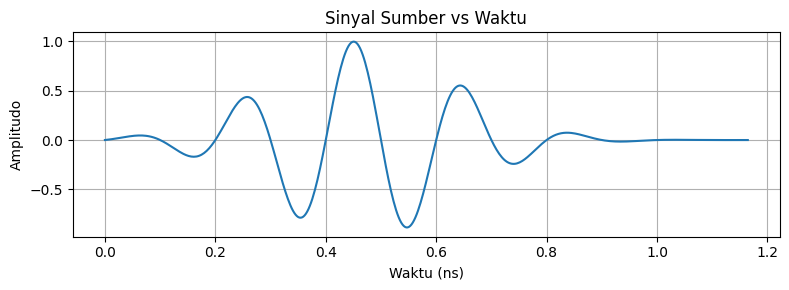

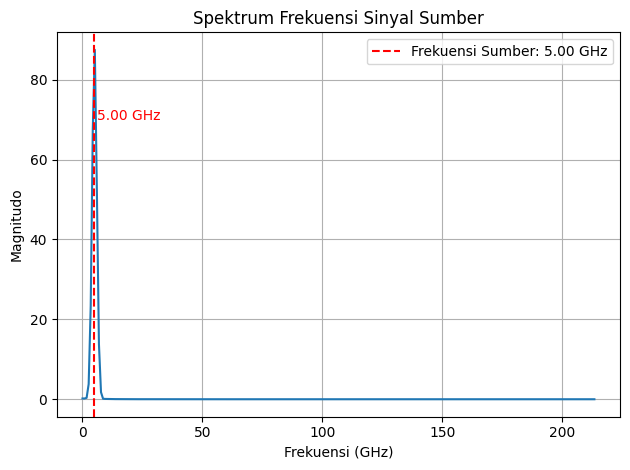

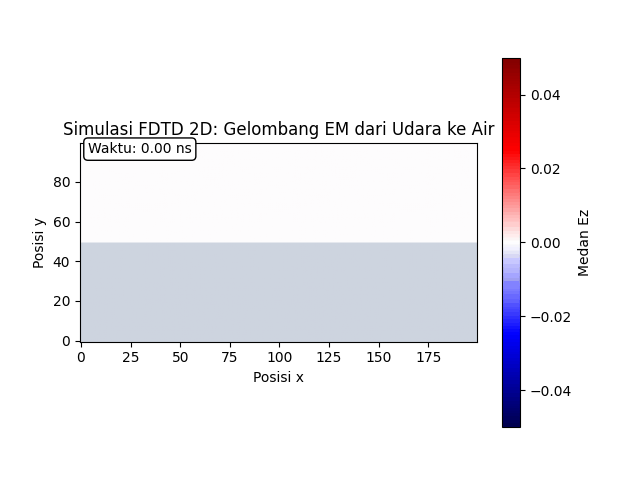

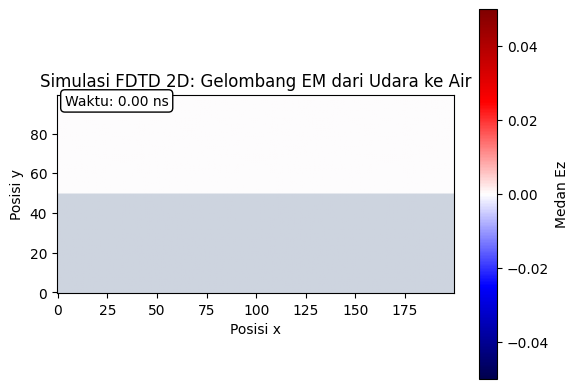

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
import os
from IPython.display import display, Image
from scipy.interpolate import interp1d

# Konstanta fisik
c0 = 3e8                 # kecepatan cahaya di vakum (m/s)
mu0 = 4 * np.pi * 1e-7   # permeabilitas vakum (H/m)
eps0 = 1 / (mu0 * c0**2) # permitivitas vakum (F/m)

# Frekuensi sumber
f_input = float(input("Masukkan frekuensi sumber (GHz): "))
f = f_input * 1e9  # Konversi ke Hz

# Parameter grid
Nx, Ny = 200, 100
Nt = 10
dx = dy = 1e-3
dt = 1 / (c0 * np.sqrt(1 / dx**2 + 1 / dy**2)) * 0.99
duration = 30

# Sinyal
source_signal = []

# Data ε′ dari tabel (25°C)
f_data = np.array([1e3, 1e6, 1e7, 1e8, 2e8, 5e8, 1e9, 2e9, 3e9, 4e9, 5e9,
                   1e10, 2e10, 3e10, 4e10, 5e10])  # Hz
eps_data = np.array([78.36, 78.36, 78.36, 78.36, 78.35, 78.31, 74.22, 72.52,
                     70.44, 73.5, 71.4, 61.81, 37.05, 28.68, 18.57, 14.64])

# Interpolasi untuk menemukan nilai permitivitas
eps_interp = interp1d(f_data, eps_data, kind='linear', fill_value='extrapolate')

# Medium: udara & air
eps_r = np.ones((Nx, Ny))
eps_r_air = eps_interp(f)  # diinterpolasi dari data
eps_r[:, 50:] = eps_r_air  # bagian air

# Inisialisasi medan
Ez = np.zeros((Nx, Ny))
Ez_prev = np.zeros((Nx, Ny))  # untuk Mur ABC
Hx = np.zeros((Nx, Ny))
Hy = np.zeros((Nx, Ny))

# Koefisien FDTD
ce = dt / (eps0 * eps_r)
chx = dt / (mu0 * dy)
chy = dt / (mu0 * dx)

# Posisi sumber
source_x, source_y = 100, 45

# Fungsi Mur ABC
def mur_boundary(Ez, Ez_prev, c, dt, dx):
    coef = (c * dt - dx) / (c * dt + dx)
    # kiri dan kanan
    Ez[0, 1:-1]   = Ez_prev[1, 1:-1]   + coef * (Ez[1, 1:-1]   - Ez_prev[0, 1:-1])
    Ez[-1, 1:-1]  = Ez_prev[-2, 1:-1]  + coef * (Ez[-2, 1:-1]  - Ez_prev[-1, 1:-1])
    # atas dan bawah
    Ez[1:-1, 0]   = Ez_prev[1:-1, 1]   + coef * (Ez[1:-1, 1]   - Ez_prev[1:-1, 0])
    Ez[1:-1, -1]  = Ez_prev[1:-1, -2]  + coef * (Ez[1:-1, -2]  - Ez_prev[1:-1, -1])
    return Ez

# Simpan frame animasi
frames = []

# Simulasi FDTD
for n in range(500):
    # Update medan H
    Hx[:, :-1] -= chx * (Ez[:, 1:] - Ez[:, :-1])
    Hy[:-1, :] += chy * (Ez[1:, :] - Ez[:-1, :])

    # Hitung curl(H)
    curl_H = np.zeros_like(Ez)
    curl_H[1:, 1:] = ((Hy[1:, 1:] - Hy[:-1, 1:]) / dx -
                      (Hx[1:, 1:] - Hx[1:, :-1]) / dy)

    Ez_prev[:] = Ez.copy()  # Simpan Ez lama

    # Update Ez
    Ez += ce * curl_H

    # Tambah sumber (sinus termodulasi Gaussian)
    s = np.exp(-((n-200) / 100) ** 2)*np.sin(2 * np.pi * f * n * dt)
    Ez[source_x, source_y] += s
    source_signal.append(s)

    # Terapkan Mur ABC
    Ez = mur_boundary(Ez, Ez_prev, c0, dt, dx)

    if n % 5 == 0:
        frames.append(Ez.copy())

# FFT sinyal sumber
sinyal_sumber = np.array(source_signal)
N = len(sinyal_sumber)
frekuensi = np.fft.fftfreq(N, dt)
spektra = np.abs(np.fft.fft(sinyal_sumber))
frekuensi_pos = frekuensi[:N // 2]
spektra_pos = spektra[:N // 2]

# Plot sinyal sumber
time = np.arange(N) * dt
plt.figure(figsize=(8, 3))
plt.plot(time * 1e9, source_signal)
plt.title("Sinyal Sumber vs Waktu")
plt.xlabel("Waktu (ns)")
plt.ylabel("Amplitudo")
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot FFT
plt.figure()
plt.plot(frekuensi_pos * 1e-9, spektra_pos)
plt.axvline(f * 1e-9, color='red', linestyle='--', label=f"Frekuensi Sumber: {f/1e9:.2f} GHz")
plt.annotate(f'{f/1e9:.2f} GHz',
             xy=(f * 1e-9, max(spektra_pos)),
             xytext=(f * 1e-9 + 1, max(spektra_pos) * 0.8),
             color='red')
plt.title("Spektrum Frekuensi Sinyal Sumber")
plt.xlabel("Frekuensi (GHz)")
plt.ylabel("Magnitudo")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Animasi
fig, ax = plt.subplots()
im_ez = ax.imshow(np.flipud(frames[0].T), cmap='seismic', vmin=-0.05, vmax=0.05, origin='lower')
im_eps = ax.imshow(np.flipud(eps_r.T), cmap='Blues', alpha=0.2, origin='lower', vmin=1, vmax=20)
plt.colorbar(im_ez, ax=ax, label='Medan Ez')
ax.set_title("Simulasi FDTD 2D: Gelombang EM dari Udara ke Air")
ax.set_xlabel("Posisi x")
ax.set_ylabel("Posisi y")

# Tambahan label waktu
time_text = ax.text(0.02, 0.95, '', transform=ax.transAxes, color='black', fontsize=10,
                    bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))

# Fungsi update untuk animasi
def update(i):
    im_ez.set_data(np.flipud(frames[i].T))
    t_now = i * 5 * dt * 1e9  # waktu dalam ns
    time_text.set_text(f"Waktu: {t_now:.2f} ns")
    return [im_ez, im_eps, time_text]

# Buat animasi
ani = FuncAnimation(fig, update, frames=len(frames), interval=duration * 5000 / Nt)

# Simpan animasi sebagai GIF
gif_path = "E:\Ikram\Belajar (non-kuliah)\CompPhys\FDTD\ simulasi.gif"
ani.save(gif_path, writer=PillowWriter(fps=20))

# Tampilkan hasil animasi
display(Image(filename=gif_path))
